In [28]:
from yaml import safe_load
from munch import munchify
from psycopg2 import connect
import pandas as pd

with open('config.yaml') as f:
    cfg = munchify(safe_load(f))
with connect(host=cfg.db.host, dbname=cfg.db.dbname,
user=cfg.db.user, password=cfg.db.psswd) as conn:
    cur = conn.cursor()

select = 'select file_name, visibilities, antennas, uv_quality, comment from uvs_apr25_test;'
cur.execute(select)
rows = cur.fetchall()

columns = [desc[0] for desc in cur.description]
df = pd.DataFrame(rows, columns=columns)
df.head()

,file_name,visibilities,antennas,uv_quality,comment
0,J1608-1625_X_2014_08_09_pus_vis.fits,91656,10,1,
1,J1608-1625_X_2018_06_13_pet_vis.fits,24264,10,1,
2,J1608-1625_S_2014_08_09_zb_vis.fits,11768,9,1,
3,J1608-1625_S_2014_08_09_pus_vis.fits,30552,10,1,
4,J1608-1625_X_2019_01_04_pet_vis.fits,6912,9,1,


In [27]:
bad_uv = df[df.uv_quality == 0]
bad_uv[bad_uv.comment.str.split().str[-1] == 'map'].head()

,file_name,visibilities,antennas,uv_quality,comment
18,J0706+3744_C_2013_10_04_lic_vis.fits,171408,9,0,J0706+3744_C_2013_10_04_lic_map.fits is a bad map
131,J0732+4335_C_2018_07_10_pet_vis.fits,1504,3,0,J0732+4335_C_2018_07_10_pet_map.fits is a bad map
190,J0533+6201_C_2016_08_06_pet_vis.fits,12976,10,0,J0533+6201_C_2016_08_06_pet_map.fits is a bad map
388,J0140-2917_C_2022_07_07_pet_vis.fits,256,4,0,J0140-2917_C_2022_07_07_pet_map.fits is a bad map
407,J2249-2634_C_2022_11_29_pet_vis.fits,96,3,0,J2249-2634_C_2022_11_29_pet_map.fits is a bad map


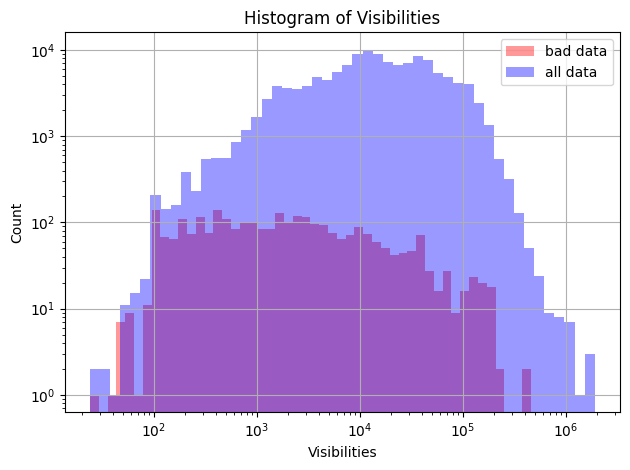

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(data=bad_uv[bad_uv.comment.str.split().str[-1] == "map"], x='visibilities', bins=50, log_scale=True,
    kde=False, alpha=0.4, edgecolor='none', color='red',
    label='bad data')
sns.histplot(data=df, x='visibilities', bins=50, log_scale=True,
    kde=False, alpha=0.4, edgecolor='none', color='blue',
    label='all data')
plt.title('Histogram of Visibilities')
plt.xlabel('Visibilities')
plt.xscale('log')
plt.ylabel('Count')
plt.yscale('log')
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

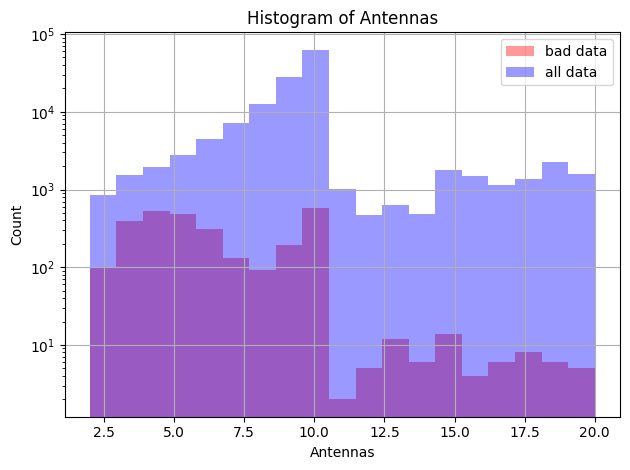

In [21]:
plt.figure()
sns.histplot(data=bad_uv[bad_uv.comment.str.split().str[-1] == "map"], x='antennas',
    bins=19, kde=False, alpha=0.4, edgecolor='none', color='red',
    label='bad data')
sns.histplot(data=df, x='antennas', 
    bins=19, kde=False, alpha=0.4, edgecolor='none', color='blue',
    label='all data')
plt.title('Histogram of Antennas')
plt.xlabel('Antennas')
plt.ylabel('Count')
plt.yscale('log')
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

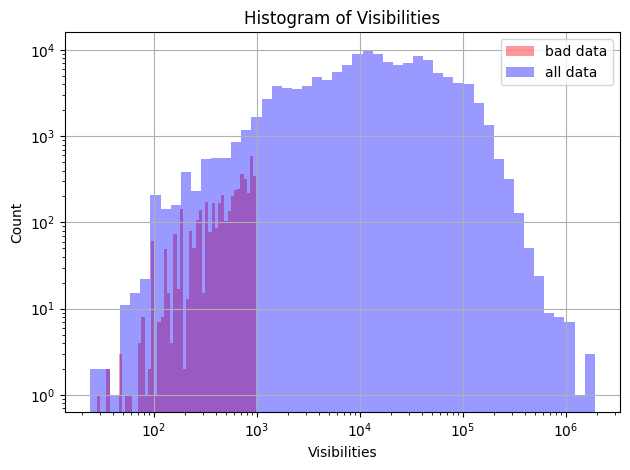

In [25]:
plt.figure()
sns.histplot(data=bad_uv[bad_uv.comment.str.split().str[-1] == "visibilities"], x='visibilities', bins=50, log_scale=True,
    kde=False, alpha=0.4, edgecolor='none', color='red',
    label='bad data')
sns.histplot(data=df, x='visibilities', bins=50, log_scale=True,
    kde=False, alpha=0.4, edgecolor='none', color='blue',
    label='all data')
plt.title('Histogram of Visibilities')
plt.xlabel('Visibilities')
plt.xscale('log')
plt.ylabel('Count')
plt.yscale('log')
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()

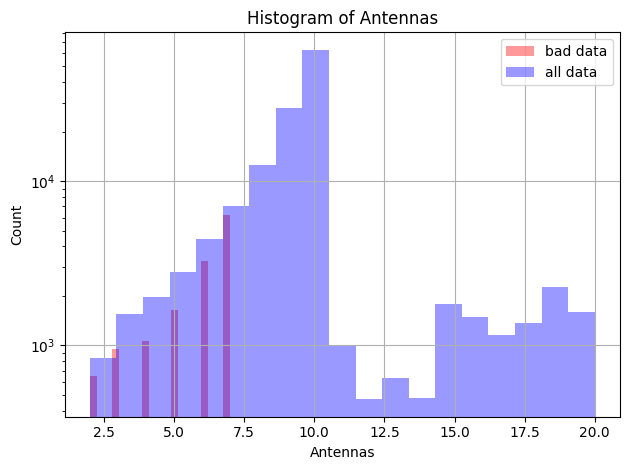

In [23]:
plt.figure()
sns.histplot(data=bad_uv[bad_uv.comment.str.split().str[-1] == "antennas"], x='antennas',
    bins=19, kde=False, alpha=0.4, edgecolor='none', color='red',
    label='bad data')
sns.histplot(data=df, x='antennas', 
    bins=19, kde=False, alpha=0.4, edgecolor='none', color='blue',
    label='all data')
plt.title('Histogram of Antennas')
plt.xlabel('Antennas')
plt.ylabel('Count')
plt.yscale('log')
plt.tight_layout()
plt.grid(True)
plt.legend()
plt.show()